# SARIMAX

### Seasonal AutoRegressive Integrated Moving Average with eXogenous regressors
So far the models we've looked at consider past values of a dataset and past errors to determine future trends, seasonality and forecasted values. We look now to models that encompass these non-seasonal (p,d,q) and seasonal (P,D,Q,m) factors, but introduce the idea that external factors (environmental, economic, etc.) can also influence a time series, and be used in forecasting.

<div class="alert alert-info"><h3>Related Functions:</h3>
<tt><strong>
<a href='https://www.statsmodels.org/stable/generated/statsmodels.tsa.statespace.sarimax.SARIMAX.html'>sarimax.SARIMAX</a></strong><font color=black>(endog[, exog, order, …])</font>&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;<br>
<strong><a href='https://www.statsmodels.org/stable/generated/statsmodels.tsa.vector_ar.var_model.VARResults.html'>sarimax.SARIMAXResults</a></strong><font color=black>(model, params, …[, …])</font>&nbsp;&nbsp;Class to hold results from fitting a SARIMAX model.</tt>

#### 1) Importing Necessary Libraires:

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.statespace.sarimax import SARIMAX
from pmdarima import auto_arima

from sklearn.metrics import mean_squared_error

#### 2) Loading Data:

In [2]:
df = pd.read_csv('RestaurantVisitors.csv', index_col= 0, parse_dates= True)

In [3]:
df.head()

,weekday,holiday,holiday_name,rest1,rest2,rest3,rest4,total
date,,,,,,,,
2016-01-01,Friday,1,New Year's Day,65.0,25.0,67.0,139.0,296.0
2016-01-02,Saturday,0,na,24.0,39.0,43.0,85.0,191.0
2016-01-03,Sunday,0,na,24.0,31.0,66.0,81.0,202.0
2016-01-04,Monday,0,na,23.0,18.0,32.0,32.0,105.0
2016-01-05,Tuesday,0,na,2.0,15.0,38.0,43.0,98.0


In [4]:
df.shape

(517, 8)

In [5]:
df.describe()

,holiday,rest1,rest2,rest3,rest4,total
count,517.000000,478.000000,478.000000,478.000000,478.000000,478.000000
mean,0.067698,37.533473,27.163180,31.548117,37.548117,133.792887
std,0.251471,21.499791,15.731851,17.820112,24.614955,59.736116
min,0.000000,1.000000,1.000000,6.000000,3.000000,40.000000
25%,0.000000,22.250000,15.000000,18.000000,19.000000,86.000000
50%,0.000000,33.000000,25.000000,24.000000,30.000000,119.000000
75%,0.000000,49.000000,38.000000,45.000000,50.000000,176.750000
max,1.000000,128.000000,91.000000,99.000000,139.000000,316.000000


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 517 entries, 2016-01-01 to 2017-05-31
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   weekday       517 non-null    object 
 1   holiday       517 non-null    int64  
 2   holiday_name  517 non-null    object 
 3   rest1         478 non-null    float64
 4   rest2         478 non-null    float64
 5   rest3         478 non-null    float64
 6   rest4         478 non-null    float64
 7   total         478 non-null    float64
dtypes: float64(5), int64(1), object(2)
memory usage: 36.4+ KB


##### Adding Index Frequency:

In [7]:
df.index

DatetimeIndex(['2016-01-01', '2016-01-02', '2016-01-03', '2016-01-04',
               '2016-01-05', '2016-01-06', '2016-01-07', '2016-01-08',
               '2016-01-09', '2016-01-10',
               ...
               '2017-05-22', '2017-05-23', '2017-05-24', '2017-05-25',
               '2017-05-26', '2017-05-27', '2017-05-28', '2017-05-29',
               '2017-05-30', '2017-05-31'],
              dtype='datetime64[ns]', name='date', length=517, freq=None)

In [8]:
df.index.freq = 'D'

In [9]:
df.index

DatetimeIndex(['2016-01-01', '2016-01-02', '2016-01-03', '2016-01-04',
               '2016-01-05', '2016-01-06', '2016-01-07', '2016-01-08',
               '2016-01-09', '2016-01-10',
               ...
               '2017-05-22', '2017-05-23', '2017-05-24', '2017-05-25',
               '2017-05-26', '2017-05-27', '2017-05-28', '2017-05-29',
               '2017-05-30', '2017-05-31'],
              dtype='datetime64[ns]', name='date', length=517, freq='D')

##### Handling Missing Values:

In [10]:
df.isna().sum()

weekday          0
holiday          0
holiday_name     0
rest1           39
rest2           39
rest3           39
rest4           39
total           39
dtype: int64

In [11]:
df.tail(40)

,weekday,holiday,holiday_name,rest1,rest2,rest3,rest4,total
date,,,,,,,,
2017-04-22,Saturday,0,na,97.0,20.0,50.0,59.0,226.0
2017-04-23,Sunday,0,na,NaN,NaN,NaN,NaN,NaN
2017-04-24,Monday,0,na,NaN,NaN,NaN,NaN,NaN
2017-04-25,Tuesday,0,na,NaN,NaN,NaN,NaN,NaN
2017-04-26,Wednesday,0,na,NaN,NaN,NaN,NaN,NaN
2017-04-27,Thursday,0,na,NaN,NaN,NaN,NaN,NaN
2017-04-28,Friday,0,na,NaN,NaN,NaN,NaN,NaN
2017-04-29,Saturday,0,na,NaN,NaN,NaN,NaN,NaN
2017-04-30,Sunday,0,na,NaN,NaN,NaN,NaN,NaN


- All missing values are at the bottom od Data.
- We can drop these rows.

In [12]:
df.dropna(inplace= True)

In [13]:
df.isna().sum()

weekday         0
holiday         0
holiday_name    0
rest1           0
rest2           0
rest3           0
rest4           0
total           0
dtype: int64

##### Visualizing Data:

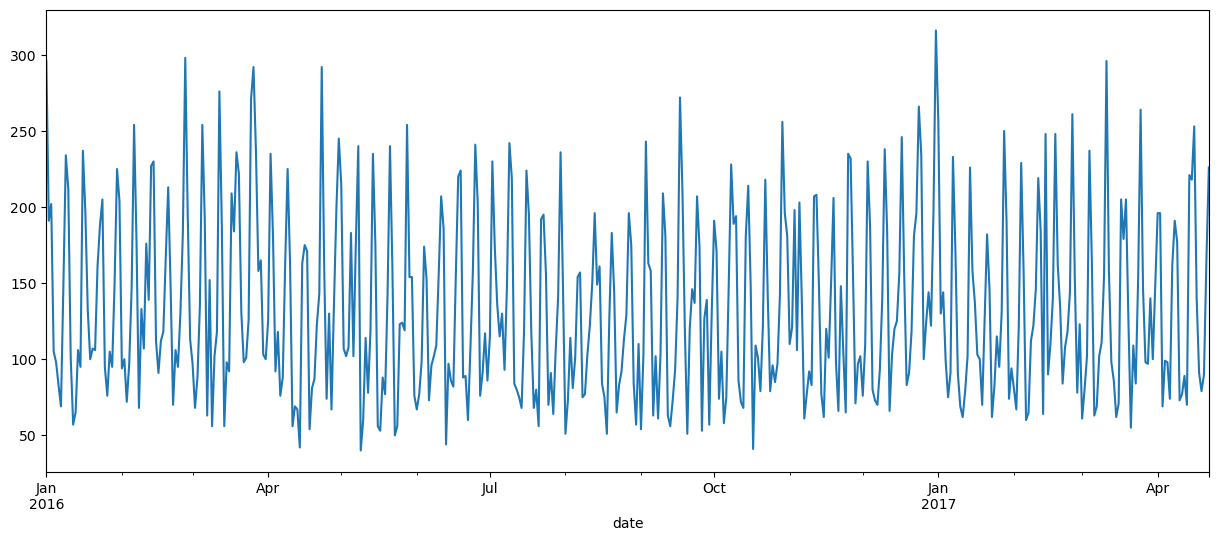

In [14]:
df['total'].plot(figsize= (15,6))
plt.show()

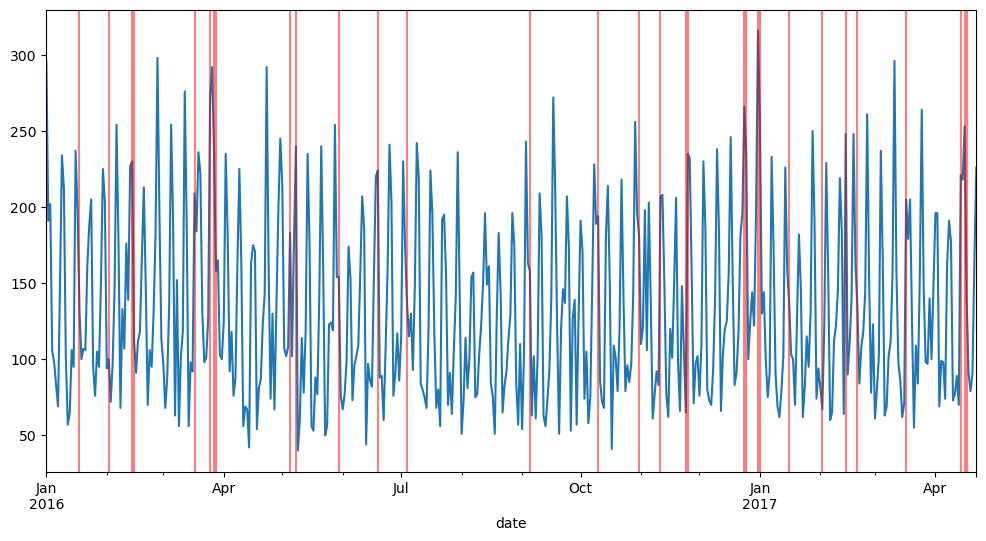

In [16]:
# Plotting Vertical Lines on Holidays to see if Total Peaks on Holidays:

ax= df["total"].plot(figsize= (12,6))

for ind in df[df["holiday"] == 1].index:
    ax.axvline(x= ind, color= "red", alpha= 0.5)
plt.show()

#### 3) ETS Decomposition:

In [17]:
decomp = seasonal_decompose(x= df['total'], 
                            model= 'additive')

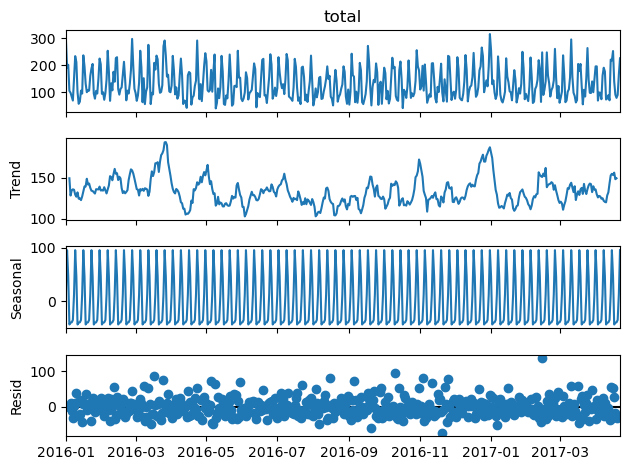

In [18]:
decomp.plot()
plt.show()

Weekly Seasonality can be observed.

#### 4) Stationarity Check:

In [19]:
from statsmodels.tsa.stattools import adfuller

def dickey_fuller_result(series):
    """
    Function To Perform Augmenter Dickey-Fuller Test and Display Results.
    """
    
    result= adfuller(series.dropna())
    
    labels = ["Test Statistics", "p-Value", "No. of Lags", "No. of Observations"]
    
    output = pd.Series(result[0:4], index= labels)
    
    for key,value in result[4].items():
        output[f"Critical Value {key}"] = value
        
    print(output)
    
    print("\n")
    
    if result[1] <= 0.05:
        print("Strong evidence against the null hypothesis.")
        print("Reject the null hypothesis.")
        print("Data has no unit root and is stationary.")
    else:
        print("Weak evidence against the null hypothesis.")
        print("Fail to reject the null hypothesis.")
        print("Data has a unit root and is non-stationary.")

In [20]:
dickey_fuller_result(df['total'])

Test Statistics         -5.592497
p-Value                  0.000001
No. of Lags             18.000000
No. of Observations    459.000000
Critical Value 1%       -3.444677
Critical Value 5%       -2.867857
Critical Value 10%      -2.570135
dtype: float64


Strong evidence against the null hypothesis.
Reject the null hypothesis.
Data has no unit root and is stationary.


#### 5) Finding Orders for SARIMAX Model using Auto Arima:

In [21]:
grid = auto_arima(y= df['total'],
                 seasonal= True,
                 m= 7,
                 trace= True)

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(1,0,1)[7] intercept   : AIC=inf, Time=1.80 sec
 ARIMA(0,0,0)(0,0,0)[7] intercept   : AIC=5269.484, Time=0.01 sec
 ARIMA(1,0,0)(1,0,0)[7] intercept   : AIC=4916.749, Time=0.90 sec
 ARIMA(0,0,1)(0,0,1)[7] intercept   : AIC=5049.644, Time=0.42 sec
 ARIMA(0,0,0)(0,0,0)[7]             : AIC=6126.084, Time=0.01 sec
 ARIMA(1,0,0)(0,0,0)[7] intercept   : AIC=5200.790, Time=0.06 sec
 ARIMA(1,0,0)(2,0,0)[7] intercept   : AIC=4845.442, Time=4.53 sec
 ARIMA(1,0,0)(2,0,1)[7] intercept   : AIC=4922.131, Time=1.54 sec
 ARIMA(1,0,0)(1,0,1)[7] intercept   : AIC=4824.849, Time=0.82 sec
 ARIMA(1,0,0)(0,0,1)[7] intercept   : AIC=5058.642, Time=0.35 sec
 ARIMA(1,0,0)(1,0,2)[7] intercept   : AIC=4927.811, Time=1.84 sec
 ARIMA(1,0,0)(0,0,2)[7] intercept   : AIC=4982.776, Time=0.84 sec
 ARIMA(1,0,0)(2,0,2)[7] intercept   : AIC=inf, Time=2.53 sec
 ARIMA(0,0,0)(1,0,1)[7] intercept   : AIC=4780.370, Time=0.91 sec
 ARIMA(0,0,0)(0,0,1)[7] intercept   : AIC=5

In [22]:
grid.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 SARIMAX Results                                 
=================================================================================
Dep. Variable:                         y   No. Observations:                  478
Model:             SARIMAX(1, 0, [1], 7)   Log Likelihood               -2386.185
Date:                   Thu, 18 Dec 2025   AIC                           4780.370
Time:                           20:51:20   BIC                           4797.049
Sample:                       01-01-2016   HQIC                          4786.927
                            - 04-22-2017                                         
Covariance Type:                     opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      6.2958      2.008      3.135      0.002       2.360      10.232
ar.S.L7        0.9557      0.014     67.354      0.000       0.928       0.984
ma.S.L7       -0.7287      0.052    -14.028      0.000      -0.831      -0.627
sigma2      1273.1127     77.849     16.354      0.000    1120.532    1425.694
===================================================================================
Ljung-Box (L1) (Q):                  16.36   Jarque-Bera (JB):                54.76
Prob(Q):                              0.00   Prob(JB):                         0.00
Heteroskedasticity (H):               0.86   Skew:                             0.70
Prob(H) (two-sided):                  0.33   Kurtosis:                         3.87
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

`(p,d,q)(P,D,Q,m) = (0,0,0)(1,0,1)[7]`

#### 6) Train Test Split:

In [23]:
len(df)

478

In [24]:
train_data = df[:436]
test_data = df[436:]
print(train_data.shape, test_data.shape)

(436, 8) (42, 8)


#### 7) SARIMA(0,0,0)(1,0,1,7) Model:

In [32]:
sarima_model = SARIMAX(endog= train_data['total'],
                      order= (0, 0, 0),
                      seasonal_order= (1, 0, 1, 7))

sarima = sarima_model.fit()

In [33]:
sarima.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 SARIMAX Results                                 
=================================================================================
Dep. Variable:                     total   No. Observations:                  436
Model:             SARIMAX(1, 0, [1], 7)   Log Likelihood               -2165.369
Date:                   Thu, 18 Dec 2025   AIC                           4336.738
Time:                           20:58:52   BIC                           4348.970
Sample:                       01-01-2016   HQIC                          4341.565
                            - 03-11-2017                                         
Covariance Type:                     opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.S.L7        0.9999   9.58e-05   1.04e+04      0.000       1.000       1.000
ma.S.L7       -0.9383      0.024    -39.198      0.000      -0.985      -0.891
sigma2      1111.8046     58.738     18.928      0.000     996.680    1226.930
===================================================================================
Ljung-Box (L1) (Q):                  15.40   Jarque-Bera (JB):                83.56
Prob(Q):                              0.00   Prob(JB):                         0.00
Heteroskedasticity (H):               0.96   Skew:                             0.72
Prob(H) (two-sided):                  0.81   Kurtosis:                         4.59
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [28]:
# Predictions on Test Data:

start = len(train_data)
end = len(train_data) + len(test_data) -1

preds = sarima.predict(start= start, end= end)

In [29]:
preds.head()

date
2017-03-12    174.735829
2017-03-13     88.792682
2017-03-14     97.318023
2017-03-15     96.004229
2017-03-16     98.930888
Freq: D, Name: predicted_mean, dtype: float64

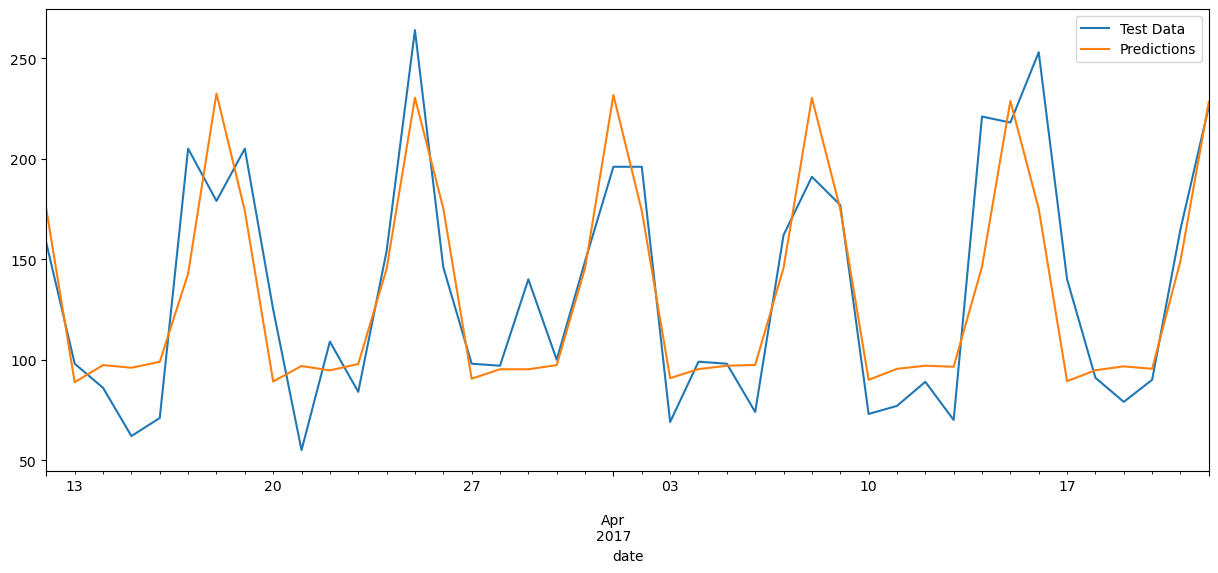

In [30]:
# Plotting Test Data and Predictions:

test_data['total'].plot(kind= 'line', figsize= (15,6), legend= True, label= 'Test Data')
preds.plot(kind= 'line', figsize= (15,6), legend= True, label= 'Predictions')
plt.show()

In [31]:
# Model Evaluation:

np.sqrt(mean_squared_error(test_data['total'], preds))

np.float64(30.334182015548944)

#### 8) SARIMAX(0,0,0)(1,0,1,7) Model with Exogenous Variable:

In [34]:
sarimax_model = SARIMAX(endog= train_data['total'],
                       exog= train_data[['holiday']],
                       order= (0, 0, 0),
                       seasonal_order= (1, 0, 1, 7))

sarimax = sarimax_model.fit()

In [35]:
sarimax.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 SARIMAX Results                                 
=================================================================================
Dep. Variable:                     total   No. Observations:                  436
Model:             SARIMAX(1, 0, [1], 7)   Log Likelihood               -2098.412
Date:                   Thu, 18 Dec 2025   AIC                           4204.823
Time:                           21:00:21   BIC                           4221.134
Sample:                       01-01-2016   HQIC                          4211.260
                            - 03-11-2017                                         
Covariance Type:                     opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
holiday       69.6441      3.968     17.550      0.000      61.866      77.422
ar.S.L7        0.9999   7.58e-05   1.32e+04      0.000       1.000       1.000
ma.S.L7       -0.9429      0.023    -40.388      0.000      -0.989      -0.897
sigma2       813.5732     47.383     17.170      0.000     720.704     906.442
===================================================================================
Ljung-Box (L1) (Q):                  15.58   Jarque-Bera (JB):                20.71
Prob(Q):                              0.00   Prob(JB):                         0.00
Heteroskedasticity (H):               1.00   Skew:                             0.23
Prob(H) (two-sided):                  1.00   Kurtosis:                         3.96
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [37]:
# Predictions on Test Data:

start = len(train_data)
end = len(train_data) + len(test_data) -1

preds = sarimax.predict(start= start, end= end, exog= test_data[['holiday']])

In [38]:
preds.head()

2017-03-12    166.667295
2017-03-13     76.818709
2017-03-14     95.892673
2017-03-15     96.778974
2017-03-16     93.457717
Freq: D, Name: predicted_mean, dtype: float64

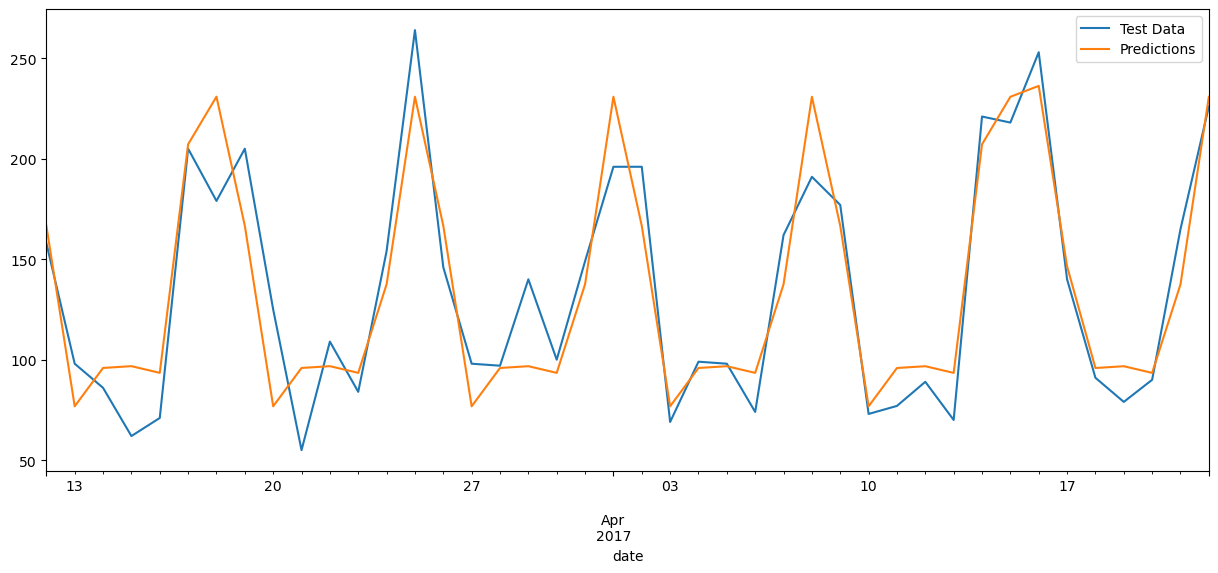

In [39]:
# Plotting Test Data and Predictions:

test_data['total'].plot(kind= 'line', figsize= (15,6), legend= True, label= 'Test Data')
preds.plot(kind= 'line', figsize= (15,6), legend= True, label= 'Predictions')
plt.show()

In [40]:
# Model Evaluation:

np.sqrt(mean_squared_error(test_data["total"], preds))

np.float64(23.214363034279362)

#### 9) Forecasting:

In [42]:
# Training Model on Full Data:

final_model = SARIMAX(df['total'], exog= df[['holiday']], order= (0,0,0), seasonal_order= (1,0,1,7))
result = final_model.fit()

In [43]:
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 SARIMAX Results                                 
=================================================================================
Dep. Variable:                     total   No. Observations:                  478
Model:             SARIMAX(1, 0, [1], 7)   Log Likelihood               -2290.874
Date:                   Thu, 18 Dec 2025   AIC                           4589.748
Time:                           21:04:26   BIC                           4606.427
Sample:                       01-01-2016   HQIC                          4596.305
                            - 04-22-2017                                         
Covariance Type:                     opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
holiday       69.9545      3.831     18.259      0.000      62.446      77.464
ar.S.L7        1.0000   4.21e-05   2.38e+04      0.000       1.000       1.000
ma.S.L7       -0.9597      0.021    -45.810      0.000      -1.001      -0.919
sigma2       783.1663     43.754     17.899      0.000     697.410     868.923
===================================================================================
Ljung-Box (L1) (Q):                  12.64   Jarque-Bera (JB):                22.24
Prob(Q):                              0.00   Prob(JB):                         0.00
Heteroskedasticity (H):               0.91   Skew:                             0.22
Prob(H) (two-sided):                  0.53   Kurtosis:                         3.96
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

We had some Rows with Missing Values for "total" in original data.
But, it had Values for "holiday".

We will Use those Values for Future Prediction.

In [44]:
orig = pd.read_csv('RestaurantVisitors.csv', index_col= 0, parse_dates= True)

In [45]:
orig.tail(40)

,weekday,holiday,holiday_name,rest1,rest2,rest3,rest4,total
date,,,,,,,,
2017-04-22,Saturday,0,na,97.0,20.0,50.0,59.0,226.0
2017-04-23,Sunday,0,na,NaN,NaN,NaN,NaN,NaN
2017-04-24,Monday,0,na,NaN,NaN,NaN,NaN,NaN
2017-04-25,Tuesday,0,na,NaN,NaN,NaN,NaN,NaN
2017-04-26,Wednesday,0,na,NaN,NaN,NaN,NaN,NaN
2017-04-27,Thursday,0,na,NaN,NaN,NaN,NaN,NaN
2017-04-28,Friday,0,na,NaN,NaN,NaN,NaN,NaN
2017-04-29,Saturday,0,na,NaN,NaN,NaN,NaN,NaN
2017-04-30,Sunday,0,na,NaN,NaN,NaN,NaN,NaN


In [46]:
holiday_values = orig[478:][["holiday"]]
holiday_values

,holiday
date,
2017-04-23,0
2017-04-24,0
2017-04-25,0
2017-04-26,0
2017-04-27,0
2017-04-28,0
2017-04-29,0
2017-04-30,0
2017-05-01,0


In [47]:
forecast = result.predict(start= len(df), end= len(df)+ 38, exog= holiday_values)

In [48]:
forecast

2017-04-23    170.395684
2017-04-24     79.734706
2017-04-25     92.343589
2017-04-26     96.106803
2017-04-27     91.202827
2017-04-28    141.875449
2017-04-29    225.419451
2017-04-30    170.390107
2017-05-01     79.732097
2017-05-02     92.340566
2017-05-03     96.103657
2017-05-04     91.199842
2017-05-05    211.825340
2017-05-06    225.412072
2017-05-07    170.384529
2017-05-08     79.729487
2017-05-09     92.337544
2017-05-10     96.100512
2017-05-11     91.196857
2017-05-12    141.866161
2017-05-13    225.404694
2017-05-14    240.333488
2017-05-15     79.726877
2017-05-16     92.334522
2017-05-17     96.097366
2017-05-18     91.193872
2017-05-19    141.861517
2017-05-20    225.397316
2017-05-21    170.373376
2017-05-22     79.724267
2017-05-23     92.331499
2017-05-24     96.094221
2017-05-25     91.190887
2017-05-26    141.856874
2017-05-27    225.389939
2017-05-28    170.367799
2017-05-29    149.676193
2017-05-30     92.328477
2017-05-31     96.091075
Freq: D, Name: predicted_

In [ ]:
# Plotting Data and Forecast:

df['total'].plot(kind= 'line', figsize= (15,6), label= 'Data', legend= True)
forecast.plot()